In [1]:
import torch
import lightning.pytorch
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct

/home/leca5365/miniconda3/envs/satclip313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting anomaly detection to True


In [3]:
# Create a toy spatio-temporal encoder
temporal_enc = LE.get_temporal_encoding("fourier", k=10)
pos_enc = LE.get_positional_encoding("sphericalharmonics")
nnet = LE.get_neural_network("siren", input_dim=temporal_enc.embedding_dim + pos_enc.embedding_dim)
ste = LE.SpatioTemporalEncoder(pos_enc, temporal_enc, nnet)

x = torch.randn(5, 3)  # 5 locations with 3 coordinates (e.g., lat, lon, time)

y = ste(x)
y.shape

torch.Size([5, 256])

In [2]:
# Create a spatio-temporal encoder from a checkpoint
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal/satclip/checkpoints/epoch62.ckpt'
lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)
lightning_model.eval()
ste = lightning_model.model.location

x = torch.randn(5, 3, device="cuda:0").double()  # 5 locations with 3 coordinates (e.g., lat, lon, time)
ste(x).shape

using vision transformer


torch.Size([5, 256])

In [6]:
# t-SNE plots of spatio-temporal embeddings
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
import mplcursors

# sample spatio-temporal coordinates
n_samples = 100
lats = torch.linspace(-90, 90, int(n_samples**0.5))
lons = torch.linspace(-180, 180, int(n_samples**0.5))
times = torch.linspace(0, 365, int(n_samples**0.5))
coords = torch.cartesian_prod(lons, lats, times).to(torch.float64)

embeddings = ste(coords.to("cuda:0")).cpu().detach().numpy()

# interactive t-SNE plot, highlight coordinates
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)


times

tensor([  0.0000,  40.5556,  81.1111, 121.6667, 162.2222, 202.7778, 243.3333,
        283.8889, 324.4445, 365.0000])

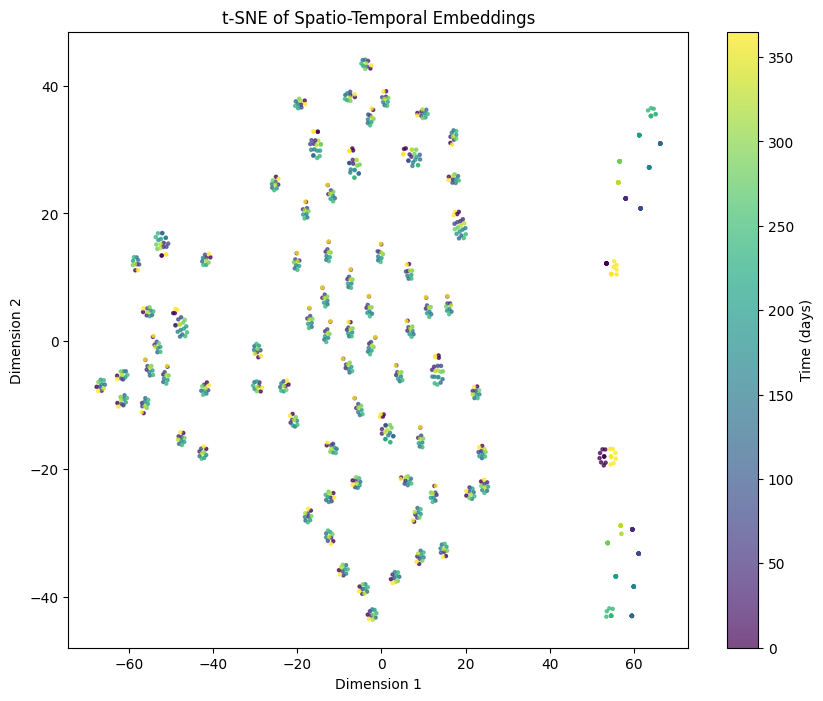

In [13]:
# Time
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 2], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Time (days)')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))

plt.show()

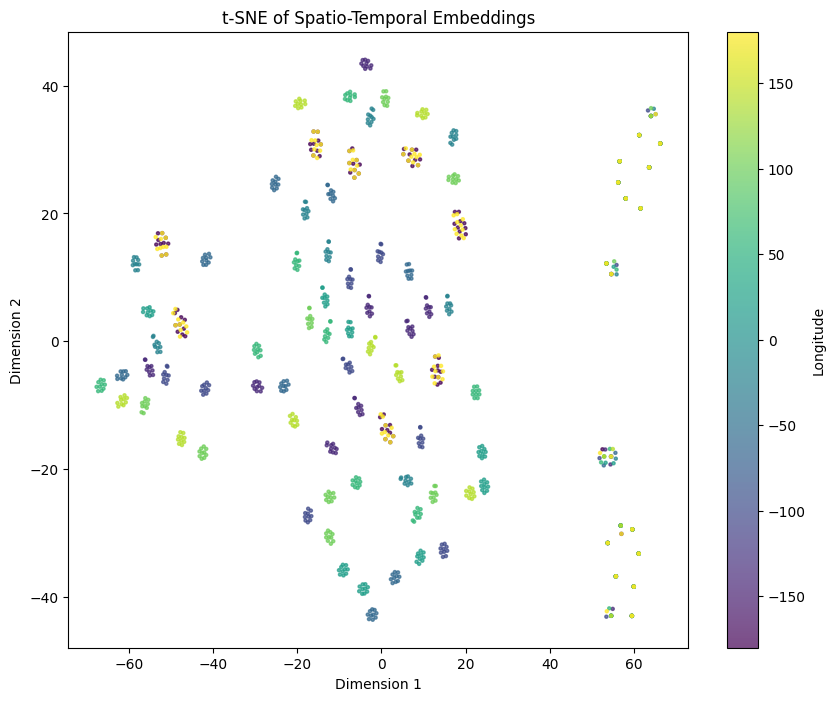

In [14]:
# Longitude
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 0], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Longitude')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))


plt.show()

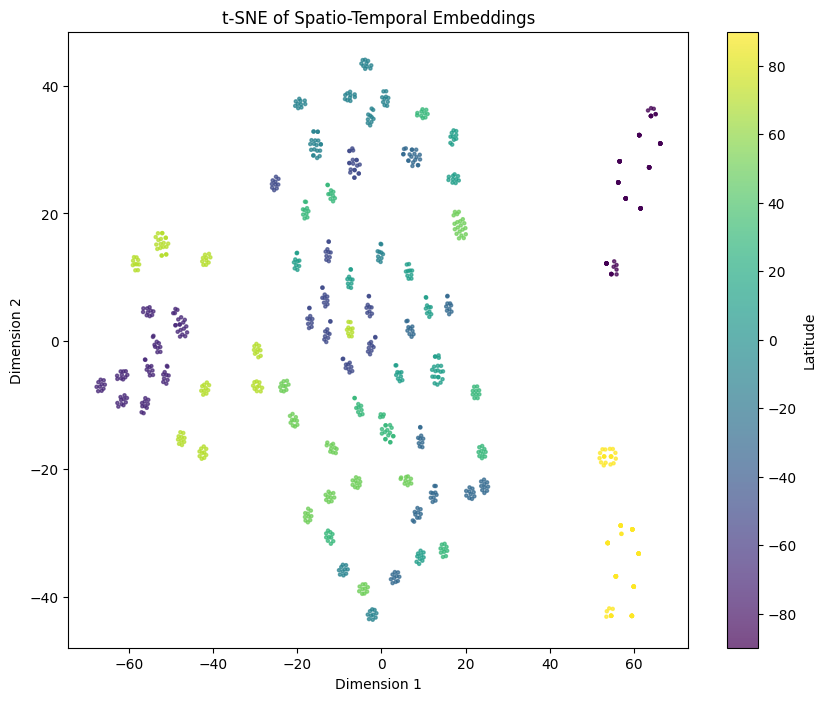

In [15]:
# Latitude
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 1], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Latitude')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))

plt.show()